# Section 1 — Query & Result

**Goal:** Select basic film-level attributes from the `film` table.

```sql
-- List all tables
SELECT name
FROM sqlite_master
WHERE type='table'
ORDER BY name;

-- Section 1: film-level attributes
SELECT
    film_id,
    rental_duration,
    length,
    replacement_cost
FROM film
ORDER BY film_id;

In [24]:
import sqlite3
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

db_path = "sqlite-sakila.db"   # replace with your actual path if needed

query_section1 = """
SELECT
    film_id,
    rental_duration,
    length,
    replacement_cost
FROM film
ORDER BY film_id;
"""

with sqlite3.connect(db_path) as conn:
    filmDf = pd.read_sql_query(query_section1, conn)

display(filmDf)

,film_id,rental_duration,length,replacement_cost
0,1,6,86,20.99
1,2,3,48,12.99
2,3,7,50,18.99
3,4,5,117,26.99
4,5,6,130,22.99
...,...,...,...,...
995,996,6,183,9.99
996,997,4,179,14.99
997,998,6,105,10.99
998,999,5,101,28.99


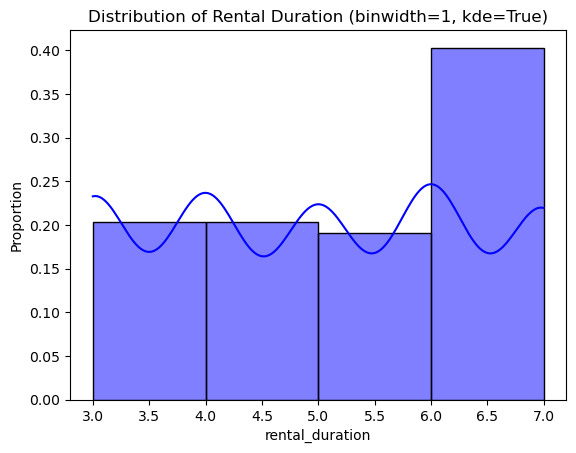

In [25]:
sns.histplot(
    data=filmDf,
    x="rental_duration",
    stat="proportion",
    binwidth=1,
    kde=True,
    color="Blue"
)
plt.title("Distribution of Rental Duration (binwidth=1, kde=True)")
plt.show()

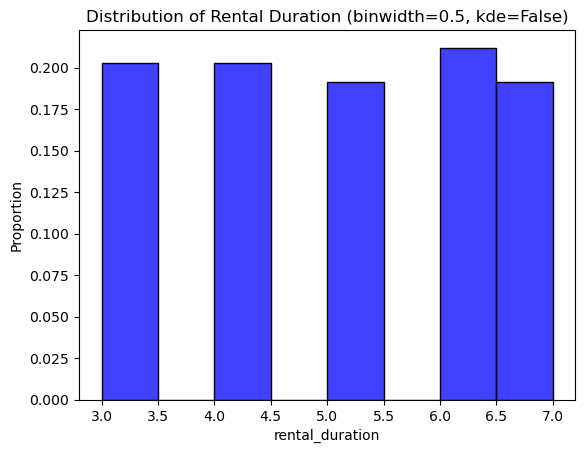

In [26]:
sns.histplot(
    data=filmDf,
    x="rental_duration",
    stat="proportion",
    binwidth=0.5,
    kde=False,
    color="Blue"
)
plt.title("Distribution of Rental Duration (binwidth=0.5, kde=False)")
plt.show()

# Section 2 — Actor Film Counts (Rating = 'G')

```sql
SELECT
    a.first_name AS Actor_First_Name,
    a.last_name  AS Actor_Last_Name,
    COUNT(f.title) AS Film_Count
FROM film f
JOIN film_actor fa ON f.film_id = fa.film_id
JOIN actor a      ON fa.actor_id = a.actor_id
WHERE f.rating = 'G'
GROUP BY Actor_First_Name, Actor_Last_Name
ORDER BY Actor_Last_Name, Actor_First_Name;

In [27]:
import sqlite3
import pandas as pd

db_path = "sqlite-sakila.db"  # adjust if needed

query_section2 = """
SELECT
    a.first_name AS Actor_First_Name,
    a.last_name  AS Actor_Last_Name,
    COUNT(f.title) AS Film_Count
FROM film f
JOIN film_actor fa ON f.film_id = fa.film_id
JOIN actor a      ON fa.actor_id = a.actor_id
WHERE f.rating = 'G'
GROUP BY Actor_First_Name, Actor_Last_Name
ORDER BY Actor_Last_Name, Actor_First_Name;
"""

with sqlite3.connect(db_path) as conn:
    actor_counts = pd.read_sql_query(query_section2, conn)

actor_counts

,Actor_First_Name,Actor_Last_Name,Film_Count
0,CHRISTIAN,AKROYD,4
1,DEBBIE,AKROYD,1
2,KIRSTEN,AKROYD,2
3,CUBA,ALLEN,5
4,KIM,ALLEN,8
...,...,...,...
193,UMA,WOOD,6
194,CAMERON,WRAY,3
195,CAMERON,ZELLWEGER,5
196,JULIA,ZELLWEGER,3


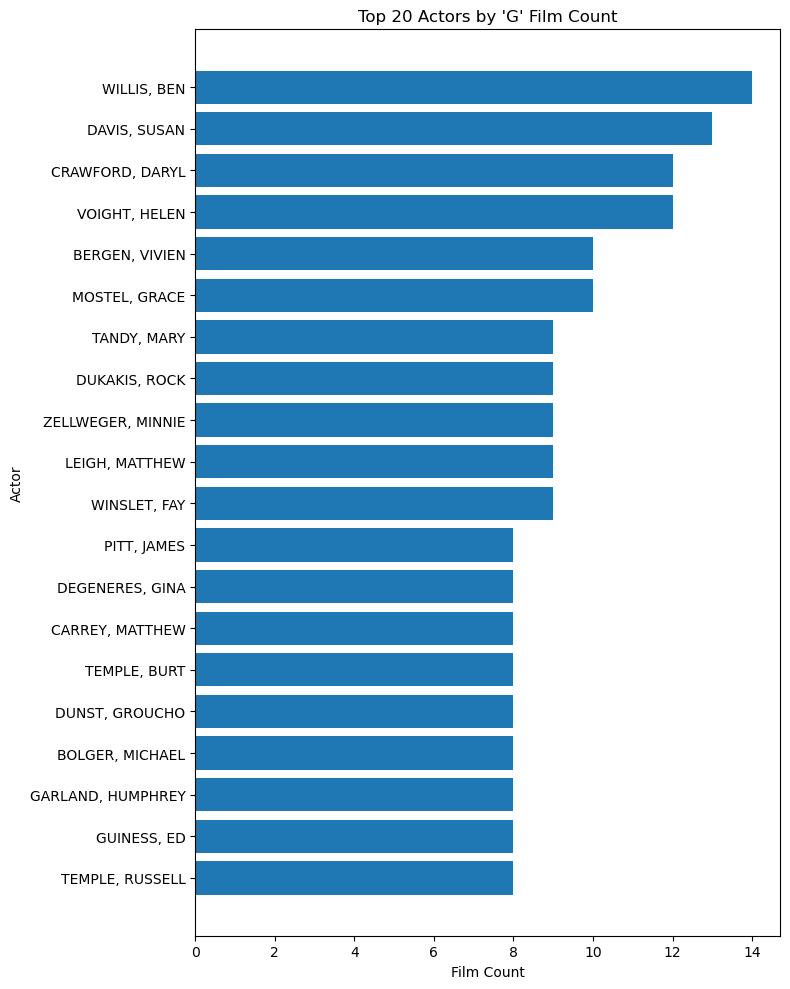

In [28]:
import matplotlib.pyplot as plt

topN = 20  # show top 20 by Film_Count
plot_df = actor_counts.sort_values("Film_Count", ascending=False).head(topN)

plt.figure(figsize=(8, 10))
plt.barh(plot_df["Actor_Last_Name"] + ", " + plot_df["Actor_First_Name"], plot_df["Film_Count"])
plt.gca().invert_yaxis()
plt.title(f"Top {topN} Actors by 'G' Film Count")
plt.xlabel("Film Count")
plt.ylabel("Actor")
plt.tight_layout()
plt.show()

# Section 3 — Category Summary (Film Count & Avg Length)

```sql
SELECT
    c.name  AS Category,
    COUNT(*) AS Film_Count,
    AVG(f.length) AS Avg_Length
FROM film f
JOIN film_category fc ON f.film_id = fc.film_id
JOIN category c       ON fc.category_id = c.category_id
GROUP BY c.name
ORDER BY Film_Count DESC, Category;

In [29]:

import sqlite3
import pandas as pd

db_path = "sqlite-sakila.db"  # adjust if needed

query_section3 = """
SELECT
    c.name  AS Category,
    COUNT(*) AS Film_Count,
    AVG(f.length) AS Avg_Length
FROM film f
JOIN film_category fc ON f.film_id = fc.film_id
JOIN category c       ON fc.category_id = c.category_id
GROUP BY c.name
ORDER BY Film_Count DESC, Category;
"""

with sqlite3.connect(db_path) as conn:
    category_summary = pd.read_sql_query(query_section3, conn)

category_summary

,Category,Film_Count,Avg_Length
0,Sports,74,128.202703
1,Foreign,73,121.698630
2,Family,69,114.782609
3,Documentary,68,108.750000
4,Animation,66,111.015152
5,Action,64,111.609375
6,New,63,111.126984
7,Drama,62,120.838710
8,Games,61,127.836066
9,Sci-Fi,61,108.196721


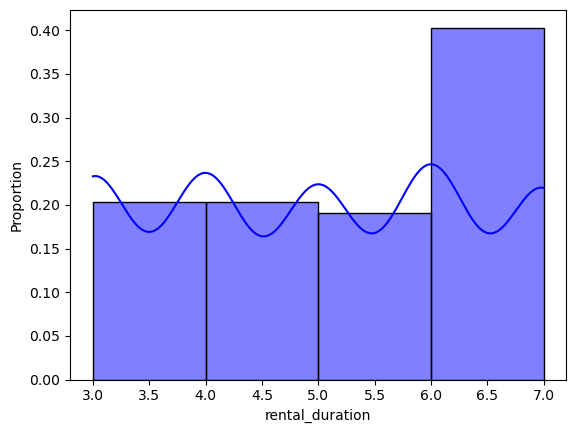

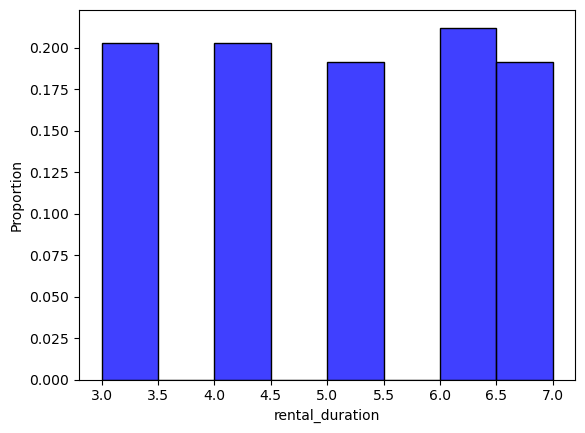

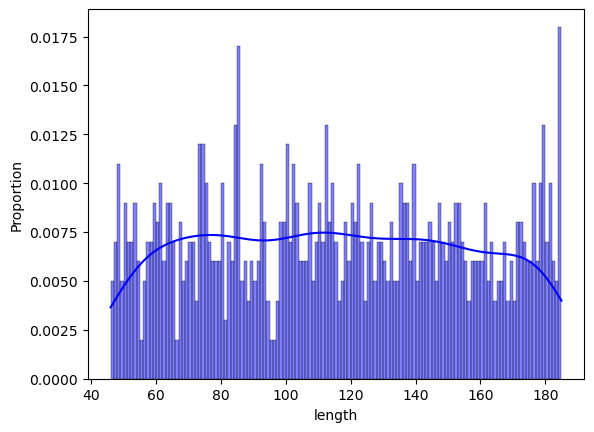

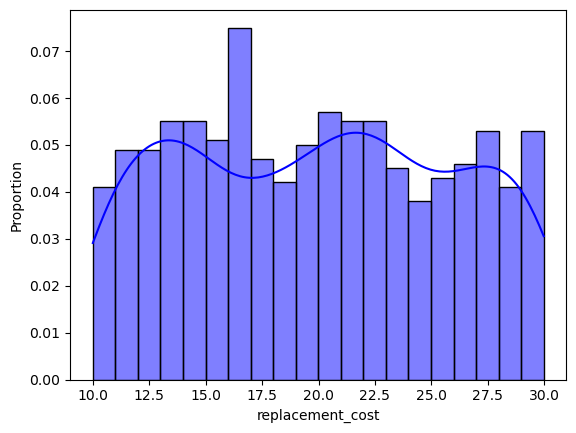

In [30]:
sns.histplot(data=filmDf, x="rental_duration", stat="proportion", binwidth=1, kde=True, color="Blue")
plt.show()

sns.histplot(data=filmDf, x="rental_duration", stat="proportion", binwidth=0.5, kde=False, color="Blue")
plt.show()

sns.histplot(data=filmDf, x="length", stat="proportion", binwidth=1, kde=True, color="Blue")
plt.show()

sns.histplot(data=filmDf, x="replacement_cost", stat="proportion", binwidth=1, kde=True, color="Blue")
plt.show()